In [2]:
#Import necessary packages
from pathlib import Path
import xarray as xr
import numpy as np

#File path
BASE = Path("/data/keeling/a/tahsina2/b/LOCA2_Illinois")

files = sorted(BASE.rglob("*.nc"))
print("Number of cropped files:", len(files))
print(files[:5])

Number of cropped files: 3853
[PosixPath('/data/keeling/a/tahsina2/b/LOCA2_Illinois/hursmax/historical/ACCESS-CM2/r1i1p1f1/hursmax.ACCESS-CM2.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20250218.Illinois.nc'), PosixPath('/data/keeling/a/tahsina2/b/LOCA2_Illinois/hursmax/historical/ACCESS-CM2/r2i1p1f1/hursmax.ACCESS-CM2.historical.r2i1p1f1.1950-2014.LOCA_16thdeg_v20250218.Illinois.nc'), PosixPath('/data/keeling/a/tahsina2/b/LOCA2_Illinois/hursmax/historical/ACCESS-CM2/r3i1p1f1/hursmax.ACCESS-CM2.historical.r3i1p1f1.1950-2014.LOCA_16thdeg_v20250218.Illinois.nc'), PosixPath('/data/keeling/a/tahsina2/b/LOCA2_Illinois/hursmax/historical/ACCESS-ESM1-5/r1i1p1f1/hursmax.ACCESS-ESM1-5.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20250218.Illinois.nc'), PosixPath('/data/keeling/a/tahsina2/b/LOCA2_Illinois/hursmax/historical/ACCESS-ESM1-5/r2i1p1f1/hursmax.ACCESS-ESM1-5.historical.r2i1p1f1.1950-2014.LOCA_16thdeg_v20250218.Illinois.nc')]


In [3]:
#Open one file to check
f = files[0]
print(f)

ds = xr.open_dataset(f)
ds

#If you want to open a specific file

# import pandas as pd

# tasks = pd.read_csv("/data/keeling/a/tahsina2/b/loca2_all_tasks.csv")
# tasks.iloc[0]

# row = tasks.iloc[0]

# out_file = (
#     BASE
#     / row["variable"]
#     / row["scenario"]
#     / row["model"]
#     / row["ensemble"]
#     / row["filename"].replace(".nc", ".Illinois.nc")
# )

# print(out_file)
# print(out_file.exists())

/data/keeling/a/tahsina2/b/LOCA2_Illinois/hursmax/historical/ACCESS-CM2/r1i1p1f1/hursmax.ACCESS-CM2.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20250218.Illinois.nc


<xarray.Dataset> Size: 663MB
Dimensions:        (time: 23741, lat: 93, lon: 75)
Coordinates:
  * time           (time) datetime64[ns] 190kB 1950-01-01T12:00:00 ... 2014-1...
  * lat            (lat) float32 372B 36.84 36.91 36.97 ... 42.47 42.53 42.59
  * lon            (lon) float32 300B 268.3 268.4 268.5 ... 272.8 272.9 273.0
Data variables:
    rel_humid_max  (time, lat, lon) float32 662MB ...
Attributes:
    SIOCRD_netCDF_Version:  1.0
    title:                  LOCA bias corrected output David Pierce SIO/CASPO
    history:                 dwpierc2 2025-01-02 15:10:43.64922 /home6/dwpier...
    loca_version:           loca_bc_hires_pr\n$Id: loca_bc_hires_pr.F90,v 1.3...

In [4]:
#Check file information

print(ds.coords)
print(list(ds.data_vars))

Coordinates:
  * time     (time) datetime64[ns] 190kB 1950-01-01T12:00:00 ... 2014-12-31T1...
  * lat      (lat) float32 372B 36.84 36.91 36.97 37.03 ... 42.47 42.53 42.59
  * lon      (lon) float32 300B 268.3 268.4 268.5 268.5 ... 272.8 272.9 273.0
['rel_humid_max']


In [5]:
#Check lat-lon bound
#Illinois bound 36.8, 42.6, -91.7, -87.0
lat = ds["lat"] if "lat" in ds.coords else ds["latitude"]
lon = ds["lon"] if "lon" in ds.coords else ds["longitude"]

print("lat min/max:", float(lat.min()), float(lat.max()))
print("lon min/max:", float(lon.min()), float(lon.max()))
print("time range:", str(ds.time.values[0]), "to", str(ds.time.values[-1]))

lat min/max: 36.84375 42.59375
lon min/max: 268.34375 272.96875
time range: 1950-01-01T12:00:00.000000000 to 2014-12-31T12:00:00.000000000


In [6]:
#Check variables

var = list(ds.data_vars)[0]

print("Variable:", var)
print("Shape:", ds[var].shape)
print("Min:", float(ds[var].min()))
print("Max:", float(ds[var].max()))
print("Mean:", float(ds[var].mean()))
print("Missing values:", int(ds[var].isnull().sum()))

Variable: rel_humid_max
Shape: (23741, 93, 75)
Min: 12.651123046875
Max: 100.0
Mean: 89.37342071533203
Missing values: 3822301


In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt

county_shp = (f"{BASE}/Illinois_County_Boundaries/IL_BNDY_County_Py.shp")

counties = gpd.read_file(county_shp).to_crs("EPSG:4326")

da = ds[var].isel(time=0)

# Convert longitude from 0-360 to -180 to 180
da = da.assign_coords(
    lon=(((da.lon + 180) % 360) - 180)
).sortby("lon")

fig, ax = plt.subplots(figsize=(8, 8))

da.plot(
    ax=ax,
    cmap="viridis",
    zorder=1
)

counties.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8,
    zorder=10
)

ax.set_xlim(float(da.lon.min()), float(da.lon.max()))
ax.set_ylim(float(da.lat.min()), float(da.lat.max()))

ax.set_title(f"{var} with Illinois County Boundaries")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

DataSourceError: /data/keeling/a/tahsina2/b/Illinois_County_Boundaries/IL_BNDY_County_Py.shp: No such file or directory

In [12]:
print(counties.crs)
print(ds.lon.min().values, ds.lon.max().values)
print(ds.lat.min().values, ds.lat.max().values)

EPSG:4326
268.34375 272.96875
36.84375 42.59375


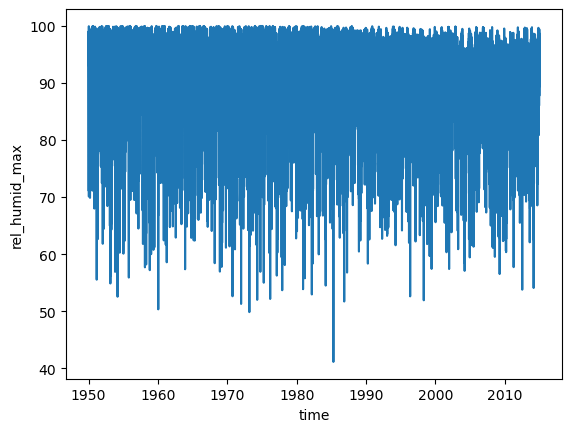

In [8]:
#Time Series

ds[var].mean(dim=[d for d in ds[var].dims if d != "time"]).plot()

In [9]:
ds.close()

In [10]:
#Check how many files have been completed

from pathlib import Path
import pandas as pd

BASE = Path("/data/keeling/a/tahsina2/b")
TASK_CSV = BASE / "loca2_all_tasks.csv"
OUT_BASE = BASE / "LOCA2_Illinois"

tasks = pd.read_csv(TASK_CSV)

def expected_output(row):
    return (
        OUT_BASE
        / row["variable"]
        / row["scenario"]
        / row["model"]
        / row["ensemble"]
        / row["filename"].replace(".nc", ".Illinois.nc")
    )

tasks["out_file"] = tasks.apply(expected_output, axis=1)
tasks["processed"] = tasks["out_file"].apply(lambda p: Path(p).exists() and Path(p).stat().st_size > 0)

total = len(tasks)
done = tasks["processed"].sum()
left = total - done

print(f"Total tasks: {total}")
print(f"Processed: {done}")
print(f"Left: {left}")
print(f"Percent done: {done / total * 100:.2f}%")

Total tasks: 4689
Processed: 3853
Left: 836
Percent done: 82.17%
